### Get Coronal Hole parameters from EUV images

This notebook processes SDO/AIA EUV FITS images (JSOC level 1.5) to derive coronal hole (CH) parameters:
- Fractional CH area ($A_{CH}$)
- CH brightness ($P_{CH}$)

See [`figures/figure1_ch_parameters.png`](../figures/figure1_ch_parameters.png) (generated by a local-only figure-generation notebook) for the full publication figure across all three latitude bands and both EUV channels.

##### Fractional CH area

$A_{CH}$ quantifies the relative area occupied by coronal holes near the solar disk center.
A central meridional region is defined in heliographic longitude, and the coronal hole mask—constructed from SPoCA coronal hole boundaries obtained via the HEK—is projected onto this region.
$A_{CH}$ is the fraction of pixels classified as coronal hole within this central region:

$$A_{CH} = \frac{N_{CH}}{N_{total}}$$

where $N_{CH}$ and $N_{total}$ are the number of CH pixels and the total number of pixels within the central meridional region, respectively.

##### CH brightness

$P_{CH}$ characterizes the EUV intensity properties of coronal holes within a fixed heliographic window on the solar disk.
A rectangular region centered on disk center (±10° in longitude, up to ±30/60/90° in latitude) is selected, and pixel intensities inside this region are extracted.
After excluding zero-value pixels and removing the upper and lower 5% of the intensity distribution, $P_{CH}$ is the sum of the reciprocals of the remaining pixel brightness values:

$$P_{CH} = \sum_{i=1}^{n} \frac{1}{b_i}$$

where $b_i$ is the brightness of pixel $i$ and $n$ is the number of pixels remaining after the outlier cuts.

In [1]:
import os, sys
import matplotlib.pyplot as plt

import sunpy

sys.path.append(os.path.abspath("../src"))
from data.ch.calibration.convert_to_level1_5 import convert_to_level1_5

euv193_fits_file = "../data/sample/aia.lev1_euv_12s.2022-10-26T150006Z.193.image_lev1.fits"
euv211_fits_file = "../data/sample/aia.lev1_euv_12s.2022-10-26T145959Z.211.image_lev1.fits"

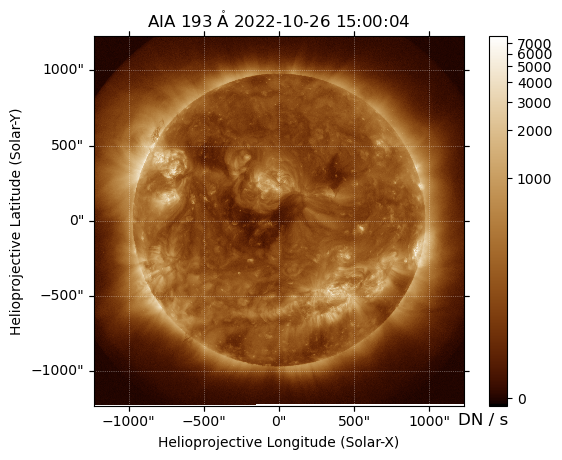

In [2]:
fits_file = euv193_fits_file
aia_map = sunpy.map.Map(euv193_fits_file)
aia_map_1_5 = convert_to_level1_5(aia_map)

aia_map_1_5.peek()

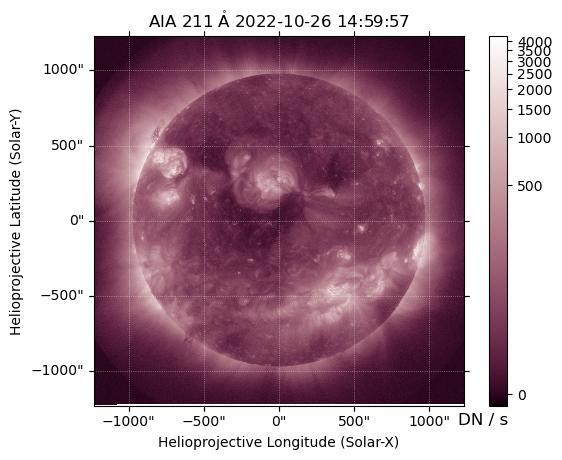

In [3]:
fits_file = euv211_fits_file
aia_map = sunpy.map.Map(fits_file)
aia_map_1_5 = convert_to_level1_5(aia_map)

aia_map_1_5.peek()

---

#### Demo: computing $A_{CH}$ and $P_{CH}$ at one latitude band

The plotting/computation helpers (`load_and_calibrate`, `get_spoca_ch_union`, `compute_A_CH`, `compute_P_metric`, ...) live in [`src/viz/ch_parameters.py`](../src/viz/ch_parameters.py) so that this notebook and the figure-generation notebook share the same code instead of duplicating it. Below is a single-latitude-band ($\pm 60°$) illustration; the full 3x3 
publication figure is in `figures/`.

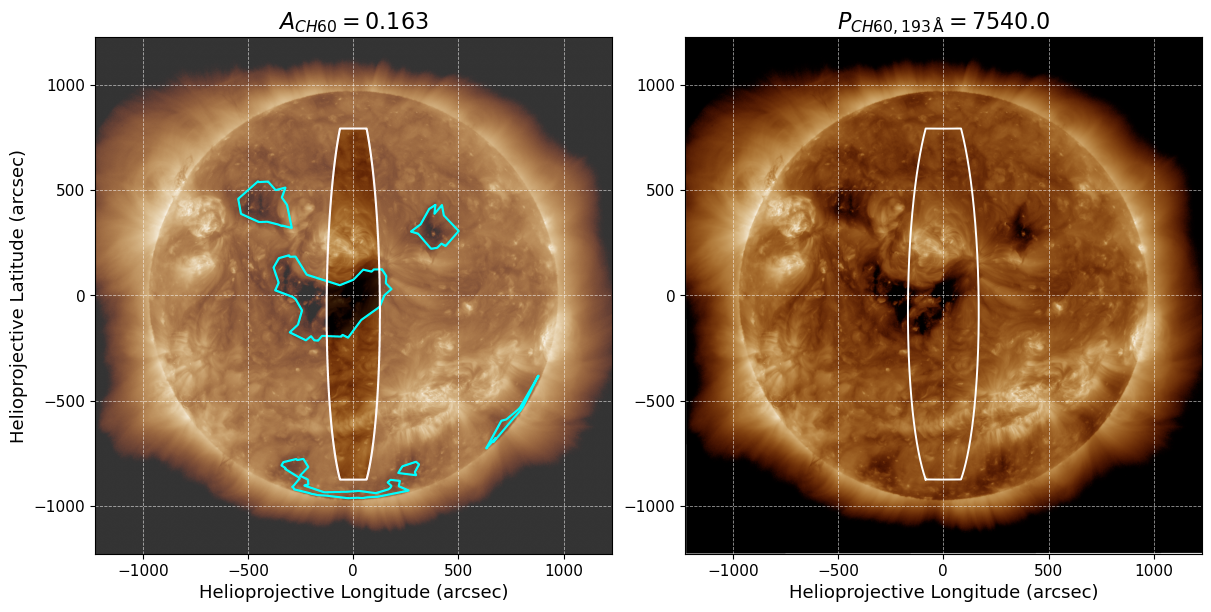

In [4]:
from viz.ch_parameters import (
    load_and_calibrate, get_spoca_ch_union, compute_A_CH, compute_P_metric,
    get_rgba_and_extent, set_hpc_axes, plot_A_panel, plot_P_panel,
)

lat_limits = [30, 60, 90]

wave193, aia193 = load_and_calibrate(euv193_fits_file)
merged_193 = get_spoca_ch_union(aia193, hours=1)
A_193, slice_masks_193, ch_mask_193 = compute_A_CH(
    aia193, merged_193, lat_limits=tuple(float(x) for x in lat_limits), lon_limit=7.5
)
P_193, xs_193, ys_193 = compute_P_metric(aia193, lat_limits=lat_limits, lon_limit=10.0)
rgba193, extent193 = get_rgba_and_extent(aia193, wave193)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
plot_A_panel(axes[0], rgba193, extent193, ch_mask_193, slice_masks_193[60.0], A_193[60.0], L=60, title_fs=16)
plot_P_panel(axes[1], rgba193, extent193, xs_193[1], ys_193[1], aia193, P_193[1], L=60, wave=wave193, title_fs=16)
set_hpc_axes(axes[0], extent193, show_ylabel=True, label_fs=13, tick_fs=11)
set_hpc_axes(axes[1], extent193, show_ylabel=False, label_fs=13, tick_fs=11)
plt.show()